# **1. Dataset Description**
The dataset provided contains customer demographic and behavioral records, which we will use to build an unsupervised clustering or segmentation model to analyze customer spending patterns. Understanding the structure and composition of this data is the foundational step in our analysis and feature engineering process.

| Column | Description |
| :--- | :--- |
| **CustomerID** | Unique identifier assigned to each customer. |
| **Gender** | The gender of the customer. |
| **Age** | The age of the customer in years. |
| **Annual Income (k$)** | The annual income of the customer in thousands of dollars. |
| **Spending Score (1-100)** | Score assigned by the customer behavior evaluation system based on purchasing habits. |

### Dataset Overview
* **Total Records:** Customer records capturing demographic profiles and purchasing metrics for market segmentation analysis.
* **Purpose:** Development of a clustering model to identify distinct customer groups for targeted marketing and behavior analysis.
* **Attributes:** The dataset encompasses key individual characteristics including age, income levels, and spending scores, allowing for a multifaceted approach to consumer profiling.

# **2. Import Libraries**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Import Dataset**

In [24]:
df = pd.read_csv('Mall_Customers.csv')

In [25]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **4. Data Preprocessing**

In [29]:
df.shape

(200, 5)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [31]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [32]:
X = df.iloc[:, [3,4]].values

We select only the `Annual Income` and `Spending Score` features to create a two-dimensional feature space that directly captures the core purchasing power and behavioral habits required for meaningful customer segmentation.

In [33]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

# **5. Model Building**

WCSS --> Within Cluster Sum of Sqaures

In [34]:
from sklearn.cluster import KMeans

In [35]:
# finding WCSS value for different number of clusters

wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

This code calculates the Within-Cluster Sum of Squares (WCSS) for K-Means clustering across a range of 1 to 10 clusters to help determine the optimal number of clusters using the elbow method.

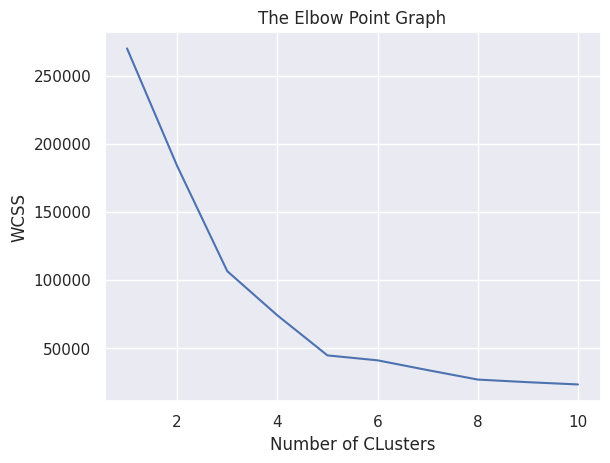

In [36]:
# plot an elbow gragh
sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of CLusters')
plt.ylabel('WCSS')
plt.show()

This code plots the WCSS values against the number of clusters to visualize the elbow point, helping to visually identify the optimal number of clusters for the K-Means algorithm.

Optimal Number of clusters = 5

### **Training the k-Means model**

In [37]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# return a label for each datapoint depending on their cluster
Y = kmeans.fit_predict(X)

This code initializes the K-Means model with 5 clusters and assigns a cluster label to each data point based on its features.

In [38]:
Y

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

Visualizing all the clusters

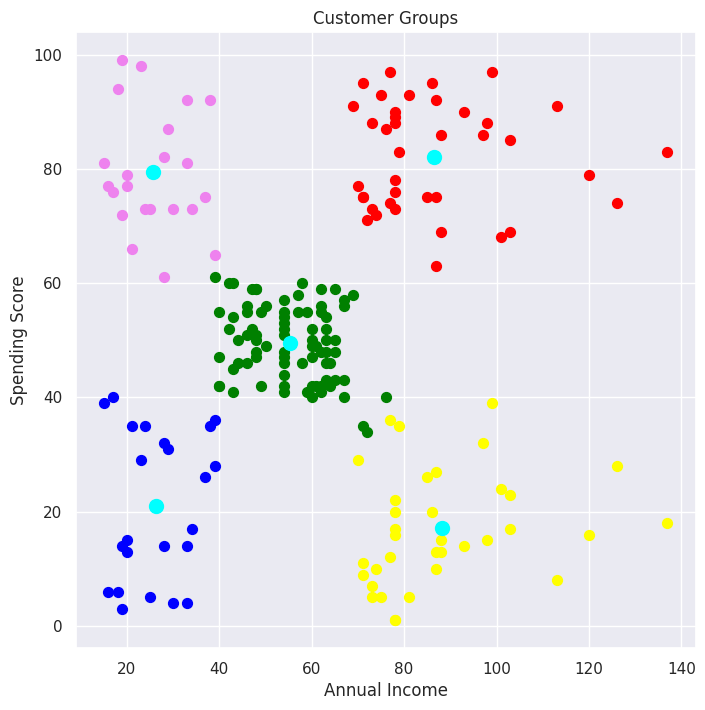

In [22]:
# plotting all the clusters and their centroids

plt.figure(figsize=(8,8))

plt.scatter(X[Y==0,0], X[Y==0,1],s=50, c='green', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1],s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1],s=50, c='violet', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1],s=50, c='yellow', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1],s=50, c='blue', label='Cluster 5')

# plot the centeroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='cyan', label='Centeroids')


plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

The scatter plot clearly visualizes five distinct customer segments based on annual income and spending score, with their respective centroids marked in cyan, revealing groups such as high-income/high-spending customers and moderate-income/moderate-spending average customers.